In [1]:
import logging
import warnings
from datetime import datetime
import os
import sys
import numpy as np
import pandas as pd
import matplotlib as mlp
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
today = datetime.now().date()

In [3]:
logging.basicConfig(
    level=logging.INFO, 
    format="%(asctime)s - %(levelname)s - %(message)s", 
    datefmt="%Y-%m-%d %H:%M:%S", 
    handlers=[
        logging.FileHandler(f"./logs/msc_data_generation_{today}.log", mode='w'), 
        logging.StreamHandler(sys.stdout)
    ]
)

Each of the subjects were shown a sequence of indoor and outdoor images each session. Now, normally, the order of this sequence is randomized. We need to hopefully find a few that are the same sequence of stimuli. We will know that those specific sessions should be the same. Thus, if $sub^{n}_{i}$, $sub^{n+x}_{j}$, and $sub^{n+y}_{k}$, with superscript referring to subject number and subscript referring to session number, all have the same sequence in their event files, we can assume that all differences between them can be discarded. We can also take the similarities between the discarded information as the inverse of the transformation all other sessions must go through to be in the same space.

In [4]:
# ---Variable Config---
config = {
    'data_dir': "../data/fmriprep_output/derivatives",
    'raw_dir': "../data/ds000224",
    'roi_mask_path': "./Sphere_Mask.nii",
    'subj_prefix': "sub-MSC",
    'sess_prefix': "ses-func",
    'task_label': "task-memoryscenes",
    'space_label': "space-MNI152NLin2009cAsym",
    'bold_suffix': "desc-preproc_bold.nii.gz",
    'mask_suffix': "desc-brain_mask.nii.gz",
    'confounds_suffix': "desc-confounds_timeseries.tsv",
    'events_suffix': 'events.tsv',
    'data_output_dir': 'datasets', 
    'roi_label': 'roi-fef_r',
    'encoding_label': 'encoding-continuous',
    'csv_suffix': 'desc-vox_w_target.csv',
    'nilearn_defaults': {
         'standardize': 'zscore_sample',
         'detrend': True,
         'low_pass': 0.1,
         'high_pass': 0.01,
         't_r': 2
        },
    'hrf_model': 'spm'
}

In [10]:
df_list = []
df_idx = []
for sub in range(1,11):
    if sub==10:
        sub = str(sub)
    else:
        sub = "0"+str(sub)
    
    for ses in range(1,15):
        if ses>9:
            ses = str(ses)
        else:
            ses = "0"+str(ses)

        p_events = os.path.join(config['raw_dir'], 
                        config['subj_prefix']+sub, 
                        config['sess_prefix']+ses, 
                        'func',  
                        "_".join([config['subj_prefix']+sub, 
                                  config['sess_prefix']+ses, 
                                  config['task_label'], 
                                  config['events_suffix']
                                 ]
                                )
                       )

        if not os.path.isfile(p_events):
            print(f"Failed: {p_events}")
            continue

        df = pd.read_csv(p_events, header=0, sep="\t")
        df['subj'] = [sub]*df.shape[0]
        df['sess'] = [ses]*df.shape[0]
        df_list.append(df)
        df_idx.append((len(df_list), sub, ses))
        print(f"Subject {sub}, session {ses}, accumulated dfs {len(df_list)}")

edf = pd.concat(df_list, axis=0, ignore_index=True)

Subject 01, session 01, accumulated dfs 1
Subject 01, session 02, accumulated dfs 2
Subject 01, session 03, accumulated dfs 3
Subject 01, session 04, accumulated dfs 4
Subject 01, session 05, accumulated dfs 5
Subject 01, session 06, accumulated dfs 6
Subject 01, session 07, accumulated dfs 7
Subject 01, session 08, accumulated dfs 8
Subject 01, session 09, accumulated dfs 9
Subject 01, session 10, accumulated dfs 10
Failed: ../data/ds000224/sub-MSC01/ses-func11/func/sub-MSC01_ses-func11_task-memoryscenes_events.tsv
Failed: ../data/ds000224/sub-MSC01/ses-func12/func/sub-MSC01_ses-func12_task-memoryscenes_events.tsv
Failed: ../data/ds000224/sub-MSC01/ses-func13/func/sub-MSC01_ses-func13_task-memoryscenes_events.tsv
Failed: ../data/ds000224/sub-MSC01/ses-func14/func/sub-MSC01_ses-func14_task-memoryscenes_events.tsv
Subject 02, session 01, accumulated dfs 11
Subject 02, session 02, accumulated dfs 12
Subject 02, session 03, accumulated dfs 13
Failed: ../data/ds000224/sub-MSC02/ses-func04/

In [7]:
trial_type_labels = dict(zip(edf.trial_type.unique(),np.arange(edf.trial_type.unique().shape[0])))
X = [df['trial_type'].map(trial_type_labels).to_numpy() for df in df_list]

In [12]:
unique_seqs = {}
for i, seq in enumerate(X):
    seq_key = tuple(seq)
    if seq_key not in unique_seqs.keys():
        unique_seqs[seq_key] = []
    unique_seqs[seq_key].append(i)

In [14]:
len(unique_seqs.keys())<len(X)

True

Okay! At least two sequences match!

In [16]:
matches = [seq for seq in unique_seqs if len(unique_seqs[seq])>1]

In [19]:
print(f"We found {len(matches)} unique sequences that were presented multiple times!")

We found 6 unique sequences that were presented multiple times!


---

Now we have to go map the matching sequences and see what we get! First, we have to find the matching runs, then the sub/sess for the runs, then we have to perform pca, then t-sne, then visualize.

In [22]:
run_groups = []
for match in matches:
    print(f"Sequences from runs {unique_seqs[match]} match!")
    run_groups.append(unique_seqs[match])

Sequences from runs [0, 28] match!
Sequences from runs [3, 21, 41, 51, 61] match!
Sequences from runs [5, 33] match!
Sequences from runs [25, 45] match!
Sequences from runs [29, 79, 89] match!
Sequences from runs [34, 84] match!


In [32]:
subj_sess_idx = [[df_list[run][['subj', 'sess']].loc[0,].astype(int).to_list() for run in runs] for runs in run_groups]

In [33]:
subj_sess_idx

[[[1, 1], [4, 1]],
 [[1, 4], [3, 4], [5, 4], [6, 4], [7, 4]],
 [[1, 6], [4, 6]],
 [[3, 8], [5, 8]],
 [[4, 2], [9, 2], [10, 2]],
 [[4, 7], [9, 7]]]

---

In [52]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import plotly.express as px

In [63]:
from matplotlib.colors import XKCD_COLORS

In [34]:
fdf = pd.read_csv("./full_fef_dataset3.csv", header=0, index_col=0)

In [59]:
seq1 = fdf[((fdf['subj']==subj_sess_idx[0][0][0]) & (fdf['sess']==subj_sess_idx[0][0][1])) | ((fdf['subj']==subj_sess_idx[0][1][0]) & (fdf['sess']==subj_sess_idx[0][1][1]))]
seq1.head()

,scan_time,v0,v1,v2,v3,v4,v5,v6,v7,v8,...,v116,v117,v118,v119,target,indoor,outdoor,sess,subj,run
0,0.0,-0.000021,0.000011,0.00001,0.000000,0.000000,0.000000,-0.000009,0.00001,0.000032,...,0.000010,-0.000072,0.000000,-0.000009,0.0,0.0,0.0,1,1,1
1,2.2,-0.000021,0.000021,0.00001,0.000000,0.000000,0.000000,-0.000009,0.00001,0.000032,...,0.000010,-0.000072,0.000000,0.000000,0.0,0.0,0.0,1,1,1
2,4.4,-0.000031,0.000011,0.00001,0.000010,-0.000011,-0.000011,-0.000009,0.00001,0.000043,...,0.000000,-0.000072,0.000000,-0.000018,0.0,0.0,0.0,1,1,1
3,6.6,-0.000021,0.000021,0.00000,-0.000010,0.000011,0.000011,0.000000,0.00001,0.000011,...,0.000019,-0.000072,0.000010,0.000026,0.0,0.0,0.0,1,1,1
4,8.8,-0.000042,0.000000,0.00002,0.000031,-0.000033,-0.000021,-0.000019,0.00002,0.000074,...,-0.000019,-0.000072,-0.000019,-0.000061,0.0,0.0,0.0,1,1,1


In [60]:
x = seq1.drop(['target', 'indoor', 'outdoor', 'scan_time', 'sess', 'subj', 'run'], axis=1)
# x_norm = StandardScaler().fit_transform(x)
y = seq1[['indoor', 'outdoor']]

In [61]:
pca = PCA()
pca_x = pca.fit_transform(x)

In [62]:
exp_var = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

Text(0, 0.5, 'Cumulative Variance Explained')

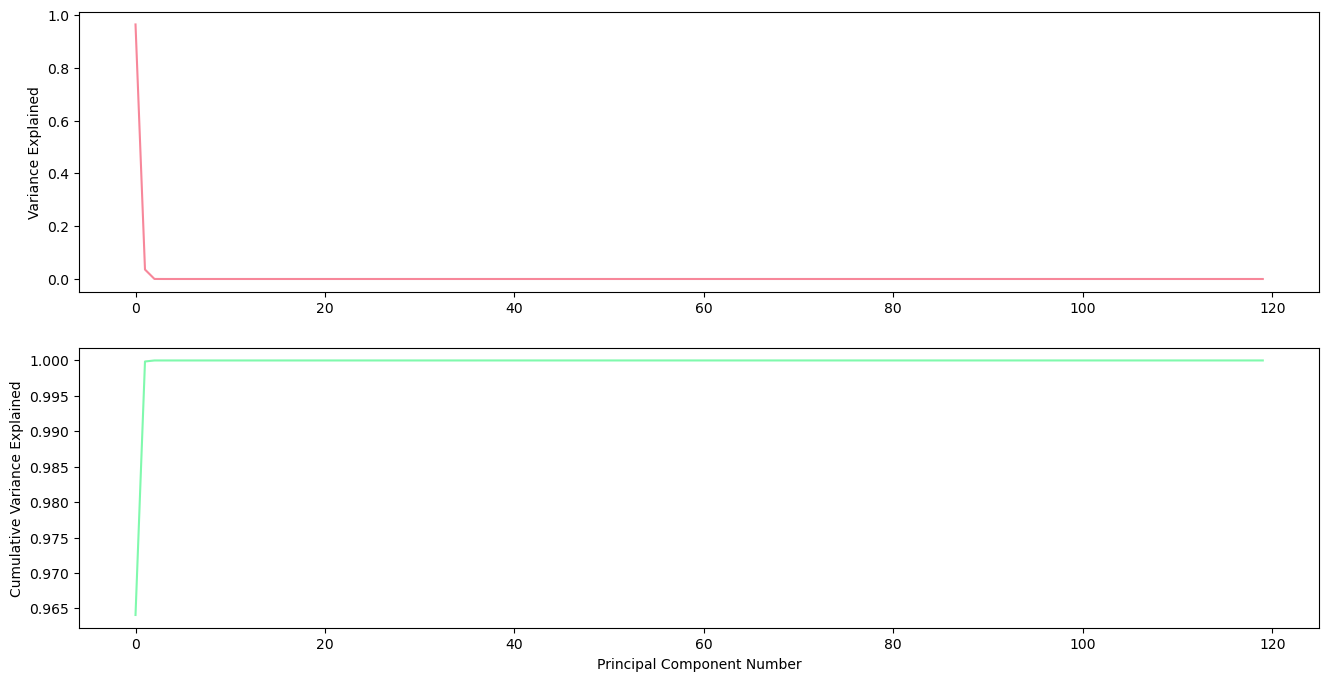

In [64]:
fig, ax = plt.subplots(2,1, figsize=(16,8))
sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
ax[1].set_xlabel("Principal Component Number")
ax[0].set_ylabel("Variance Explained")
ax[1].set_ylabel("Cumulative Variance Explained")

This actually makes a lot of sense for a dataset where both subjects saw the same sequence of events.

In [65]:
cum_exp_var[:10]

array([0.9640583 , 0.99985291, 0.99999764, 0.9999977 , 0.99999776,
       0.99999781, 0.99999786, 0.99999792, 0.99999797, 0.99999802])

In [66]:
x10pc = pca_x[:,0:10]

In [ ]:
tsne = TSNE(n_components=3, 
            perplexity=30, 
            random_state=42
           )
tsne_3d = tsne.fit_transform(x10pc)

In [76]:
tsne_df = pd.DataFrame(tsne_3d, columns=['x', 'y', 'z'])
tsne_df['Time'] = seq1['scan_time'].to_list()
tsne_df['Subjects'] = seq1['subj'].to_list()
tsne_df['Run'] = seq1['run'].to_list()
tsne_df['Session'] = seq1['sess'].to_list()

In [77]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Subjects', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Subject")
fig.show(renderer="iframe")

In [79]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Time', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Scan Time")
fig.show(renderer="iframe")

In [80]:
seq2 = fdf[((fdf['subj']==subj_sess_idx[1][0][0]) & 
            (fdf['sess']==subj_sess_idx[1][0][1])) | ((fdf['subj']==subj_sess_idx[1][1][0]) & 
                                                      (fdf['sess']==subj_sess_idx[1][1][1])) | ((fdf['subj']==subj_sess_idx[1][2][0]) & 
                                                                                                (fdf['sess']==subj_sess_idx[1][2][1])) | ((fdf['subj']==subj_sess_idx[1][3][0]) & 
                                                                                                                                          (fdf['sess']==subj_sess_idx[1][3][1])) | ((fdf['subj']==subj_sess_idx[1][4][0]) & 
                                                                                                                                                                                    (fdf['sess']==subj_sess_idx[1][4][1]))]
seq2.head()

,scan_time,v0,v1,v2,v3,v4,v5,v6,v7,v8,...,v116,v117,v118,v119,target,indoor,outdoor,sess,subj,run
363,0.0,0.000065,0.00000,-0.000018,0.000000,0.00000,0.000037,-0.000017,-0.000061,0.000000,...,0.000017,-0.000018,0.000017,0.000008,0.0,0.0,0.0,4,1,4
364,2.2,0.000065,0.00000,-0.000018,0.000000,0.00000,0.000037,-0.000017,-0.000061,0.000009,...,0.000009,-0.000027,0.000017,0.000008,0.0,0.0,0.0,4,1,4
365,4.4,0.000065,0.00000,-0.000018,-0.000009,-0.00001,0.000037,-0.000017,-0.000061,0.000000,...,0.000017,-0.000018,0.000017,0.000016,0.0,0.0,0.0,4,1,4
366,6.6,0.000065,-0.00001,-0.000018,0.000009,0.00001,0.000028,-0.000025,-0.000061,0.000009,...,0.000009,-0.000035,0.000009,0.000000,0.0,0.0,0.0,4,1,4
367,8.8,0.000065,0.00001,-0.000027,-0.000018,-0.00002,0.000046,-0.000008,-0.000061,0.000000,...,0.000026,0.000009,0.000026,0.000033,0.0,0.0,0.0,4,1,4


In [81]:
x = seq2.drop(['target', 'indoor', 'outdoor', 'scan_time', 'sess', 'subj', 'run'], axis=1)
# x_norm = StandardScaler().fit_transform(x)
y = seq2[['indoor', 'outdoor']]

In [82]:
pca = PCA()
pca_x = pca.fit_transform(x)

In [83]:
exp_var = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

Text(0, 0.5, 'Cumulative Variance Explained')

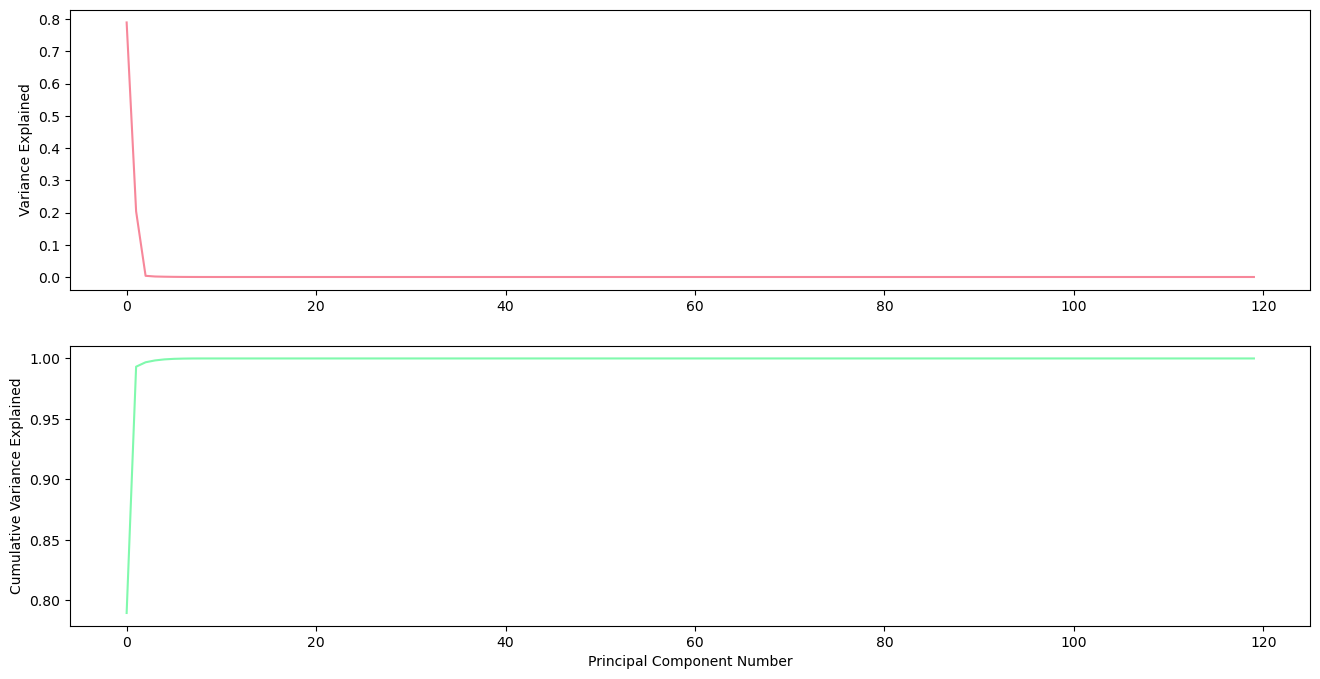

In [84]:
fig, ax = plt.subplots(2,1, figsize=(16,8))
sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
ax[1].set_xlabel("Principal Component Number")
ax[0].set_ylabel("Variance Explained")
ax[1].set_ylabel("Cumulative Variance Explained")

In [85]:
cum_exp_var[:10]

array([0.78957856, 0.99319851, 0.99683568, 0.99837488, 0.99923587,
       0.99967765, 0.99988413, 0.99997706, 0.99999515, 0.99999529])

In [86]:
x10pc = pca_x[:,0:10]

In [89]:
tsne = TSNE(n_components=3, 
            perplexity=30, 
            random_state=42
           )
tsne_3d = tsne.fit_transform(x10pc)

In [95]:
tsne_df = pd.DataFrame(tsne_3d, columns=['x', 'y', 'z'])
tsne_df['Time'] = seq2['scan_time'].to_list()
tsne_df['Subjects'] = seq2['subj'].to_list()
tsne_df['Run'] = seq2['run'].to_list()
tsne_df['Session'] = seq2['sess'].to_list()
tsne_df['Target'] = seq2['target'].to_list()

In [92]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Subjects', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Subject")
fig.show(renderer="iframe")

In [93]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Time', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Scan Time")
fig.show(renderer="iframe")

In [96]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Target', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor to Outdoor Strength")
fig.show(renderer="iframe")

In [99]:
tsne_df['Indoor'] = seq2['indoor'].to_list()
tsne_df['Outdoor'] = seq2['outdoor'].to_list()
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Indoor', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor Strength")
fig.show(renderer="iframe")

In [100]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Outdoor', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor Strength")
fig.show(renderer="iframe")

In [103]:
x10pcdf = pd.DataFrame(dict(zip(['PC'+str(n) for n in np.arange(10)], [x10pc[:,n] for n in np.arange(x10pc.shape[1])])))
x10pcdf['Time'] = seq2['scan_time'].to_list()
x10pcdf['Subjects'] = seq2['subj'].to_list()
x10pcdf['Run'] = seq2['run'].to_list()
x10pcdf['Session'] = seq2['sess'].to_list()
x10pcdf['Target'] = seq2['target'].to_list()
x10pcdf['Indoor'] = seq2['indoor'].to_list()
x10pcdf['Outdoor'] = seq2['outdoor'].to_list()
fig = px.scatter_3d(x10pcdf, x='PC0', y='PC1', z='PC2', color='Indoor', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor Strength")
fig.show(renderer="iframe")

In [105]:
fig = px.scatter_3d(x10pcdf, x='PC0', y='PC1', z='PC2', color='Outdoor', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Outdoor Strength")
fig.show(renderer="iframe")

In [106]:
fig = px.scatter_3d(x10pcdf, x='PC0', y='PC1', z='PC2', color='Target', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor Strength")
fig.show(renderer="iframe")

In [107]:
fig = px.scatter_3d(x10pcdf, x='PC3', y='PC1', z='PC2', color='Target', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor Strength")
fig.show(renderer="iframe")

In [112]:
fig = px.scatter_3d(x10pcdf, x='PC3', y='PC1', z='PC2', color='Subjects', opacity=0.7, size_max=3, title="PCA of FEF by Subject")
fig.show(renderer="iframe")

In [111]:
fig = px.scatter_3d(x10pcdf, x='PC3', y='PC4', z='PC2', color='Subjects', opacity=0.7, size_max=3, title="PCA of FEF by Subject")
fig.show(renderer="iframe")

In [113]:
fig = px.scatter_3d(x10pcdf, x='PC3', y='PC4', z='PC5', color='Subjects', opacity=0.7, size_max=3, title="PCA of FEF by Subject")
fig.show(renderer="iframe")

In [114]:
fig = px.scatter_3d(x10pcdf, x='PC6', y='PC4', z='PC5', color='Subjects', opacity=0.7, size_max=3, title="PCA of FEF by Subject")
fig.show(renderer="iframe")

This needs some more preprocessing.

---------------

In [118]:
from sklearn.preprocessing import StandardScaler
from scipy.linalg import orthogonal_procrustes

In [119]:
x = fdf.drop(['target', 'indoor', 'outdoor', 'scan_time', 'sess', 'subj', 'run'], axis=1)
# x_norm = StandardScaler().fit_transform(x)
y = fdf[['indoor', 'outdoor']]

In [120]:
for run in fdf['run'].unique():
    idx_run = fdf.index[fdf['run']==run].to_list()
    scaler = StandardScaler()
    x.loc[idx_run,:] = scaler.fit_transform(x.loc[idx_run,:])

Just need a quick and dirty update of seq2.

In [128]:
update_cols = list(set(seq2.columns).intersection(x.columns))
len(update_cols)

120

In [129]:
seq2.loc[:,update_cols] = x.loc[seq2.index,:]

In [130]:
seq2.head()

,scan_time,v0,v1,v2,v3,v4,v5,v6,v7,v8,...,v116,v117,v118,v119,target,indoor,outdoor,sess,subj,run
363,0.0,-0.18294,0.003822,0.004966,0.001894,0.001647,0.001682,0.000697,0.007356,-0.007933,...,0.002561,0.001381,0.002738,-0.000486,0.0,0.0,0.0,4,1,4
364,2.2,-0.18294,0.003822,0.004966,0.001894,0.001647,0.001682,0.000697,0.007356,0.006183,...,-0.003398,-0.001230,0.002738,-0.000486,0.0,0.0,0.0,4,1,4
365,4.4,-0.18294,0.003822,0.004966,-0.002600,-0.003334,0.001682,0.000697,0.007356,-0.007933,...,0.002561,0.001381,0.002738,0.002972,0.0,0.0,0.0,4,1,4
366,6.6,-0.18294,-0.005616,0.004966,0.006389,0.006628,-0.006798,-0.005329,0.007356,0.006183,...,-0.003398,-0.003841,-0.006465,-0.003943,0.0,0.0,0.0,4,1,4
367,8.8,-0.18294,0.013261,-0.010441,-0.007094,-0.008316,0.010161,0.006724,0.007356,-0.007933,...,0.008520,0.009214,0.011940,0.009887,0.0,0.0,0.0,4,1,4


From our analysis above, we know that these strands are not aligned. First, let's check how they look. Then we gotta compute the transformation matrix that aligns one strand to another. 

In [132]:
pca = PCA()
pca_seq2 = pca.fit_transform(seq2.loc[:,update_cols])

In [133]:
exp_var = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

Text(0, 0.5, 'Cumulative Variance Explained')

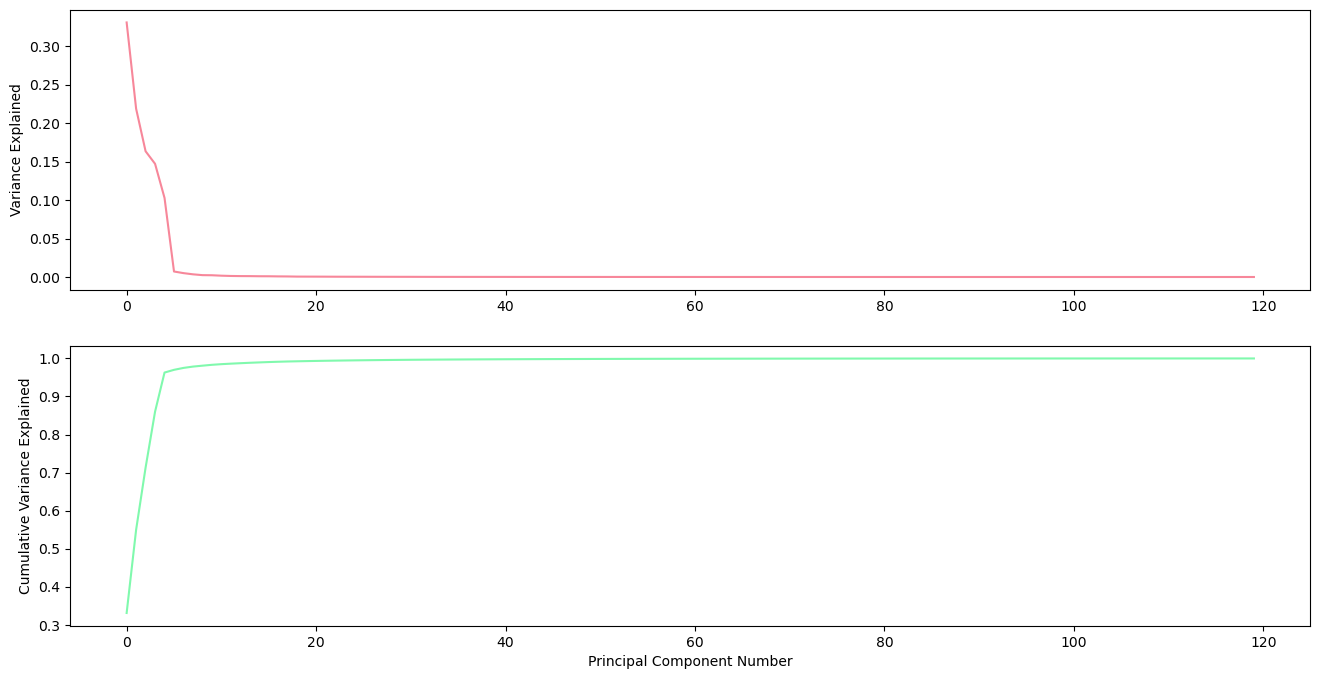

In [134]:
fig, ax = plt.subplots(2,1, figsize=(16,8))
sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
ax[1].set_xlabel("Principal Component Number")
ax[0].set_ylabel("Variance Explained")
ax[1].set_ylabel("Cumulative Variance Explained")

In [138]:
cum_exp_var[:25]

array([0.33085579, 0.5495959 , 0.7130226 , 0.86013937, 0.96293217,
       0.97007334, 0.97510587, 0.97858715, 0.98099955, 0.98326919,
       0.98497159, 0.9863099 , 0.98748615, 0.98861302, 0.98959094,
       0.99053152, 0.99131702, 0.99202199, 0.99253528, 0.99302045,
       0.9934851 , 0.99390723, 0.99427824, 0.99462513, 0.99495011])

In [139]:
x25pc = pca_seq2[:,0:25]

In [140]:
tsne = TSNE(n_components=3, 
            perplexity=30, 
            random_state=42
           )
tsne_3d = tsne.fit_transform(x25pc)

In [141]:
tsne_df = pd.DataFrame(tsne_3d, columns=['x', 'y', 'z'])
tsne_df['Time'] = seq2['scan_time'].to_list()
tsne_df['Subjects'] = seq2['subj'].to_list()
tsne_df['Run'] = seq2['run'].to_list()
tsne_df['Session'] = seq2['sess'].to_list()
tsne_df['Target'] = seq2['target'].to_list()

In [142]:
fig = px.scatter_3d(tsne_df, x='x', y='y', z='z', color='Subjects', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Subject")
fig.show(renderer="iframe")

In [143]:
x25pcdf = pd.DataFrame(dict(zip(['PC'+str(n) for n in np.arange(25)], [x25pc[:,n] for n in np.arange(x25pc.shape[1])])))
x25pcdf['Time'] = seq2['scan_time'].to_list()
x25pcdf['Subjects'] = seq2['subj'].to_list()
x25pcdf['Run'] = seq2['run'].to_list()
x25pcdf['Session'] = seq2['sess'].to_list()
x25pcdf['Target'] = seq2['target'].to_list()
x25pcdf['Indoor'] = seq2['indoor'].to_list()
x25pcdf['Outdoor'] = seq2['outdoor'].to_list()
fig = px.scatter_3d(x25pcdf, x='PC0', y='PC1', z='PC2', color='Indoor', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor Strength")
fig.show(renderer="iframe")

In [144]:
fig = px.scatter_3d(x25pcdf, x='PC0', y='PC1', z='PC2', color='Outdoor', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Outdoor Strength")
fig.show(renderer="iframe")

In [145]:
fig = px.scatter_3d(x25pcdf, x='PC0', y='PC1', z='PC2', color='Target', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor Strength")
fig.show(renderer="iframe")

In [146]:
fig = px.scatter_3d(x25pcdf, x='PC3', y='PC1', z='PC2', color='Target', opacity=0.7, size_max=3, title="3D t-SNE of Brain States by Indoor Strength")
fig.show(renderer="iframe")

In [147]:
fig = px.scatter_3d(x25pcdf, x='PC3', y='PC1', z='PC2', color='Subjects', opacity=0.7, size_max=3, title="PCA of FEF by Subject")
fig.show(renderer="iframe")

In [148]:
fig = px.scatter_3d(x25pcdf, x='PC3', y='PC4', z='PC2', color='Subjects', opacity=0.7, size_max=3, title="PCA of FEF by Subject")
fig.show(renderer="iframe")

In [149]:
fig = px.scatter_3d(x25pcdf, x='PC3', y='PC4', z='PC5', color='Subjects', opacity=0.7, size_max=3, title="PCA of FEF by Subject")
fig.show(renderer="iframe")

In [150]:
fig = px.scatter_3d(x25pcdf, x='PC6', y='PC4', z='PC5', color='Subjects', opacity=0.7, size_max=3, title="PCA of FEF by Subject")
fig.show(renderer="iframe")

So, subject 3 (purple) is either the best subject or the worst one. However, if we want to align, we probably don't want to use the outlier as a template. Looking at the above charts, let's try subject 6 and see how well they do.

In [155]:
x25pcdf.Subjects.unique()

array([1, 3, 5, 6, 7])

In [166]:
s2idx = [seq2[seq2['subj']==x].index.to_list() for x in x25pcdf.Subjects.unique()]

In [186]:
master_tmat_list = []
master_corr_list = []
for i, s in enumerate(x25pcdf.Subjects.unique()):
    tmat_list = []
    corr_list = []
    for run in s2idx:
        target = x.loc[s2idx[i],:].to_numpy()
        transforming_matrix = x.loc[run,:].to_numpy()
        transformation_matrix, _ = orthogonal_procrustes(transforming_matrix, target)
        transformed_matrix = transforming_matrix @ transformation_matrix    
        tmat_list.append(transformation_matrix)
        corr_list.append(np.corrcoef(transformed_matrix.flatten(),target.flatten())[0,1])
    master_tmat_list.append((s, tmat_list))
    master_corr_list.append((s, corr_list))

In [191]:
total_similarity = [(master_corr_list[i][0], sum(master_corr_list[i][1])-1) for i in range(len(master_corr_list))]

In [192]:
total_similarity

[(np.int64(1), np.float64(1.187871672292034)),
 (np.int64(3), np.float64(0.3566529752520369)),
 (np.int64(5), np.float64(0.34864397672675884)),
 (np.int64(6), np.float64(1.117672190456954)),
 (np.int64(7), np.float64(0.4913939885348846))]